# Pràctica 2 — Clustering K-means: segmentació del mercat

**Input:** `data/processed/pisos_clean.parquet` (FASE 2)

**Objectiu:** descobrir segments naturals del mercat immobiliari català
sense usar etiquetes — agrupar anuncis per la seva combinació de
`log_price_per_m2 × log_area_m2 × rooms × bathrooms × antiguitat ×
energy_cert × dist_bcn_km` i interpretar els grups resultants.

**Decisions metodològiques:**
- **Estandardització** (StandardScaler) — k-means usa distància euclidiana,
  imprescindible.
- **Selecció de k** combinant **mètode del colze** (inèrcia) i
  **coeficient de silueta**.
- `random_state=42` i `n_init=20` per a reproductibilitat.
- Silueta computada sobre submostra (N=5.000) per escalabilitat.


## 0. Setup

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100


def find_project_root(start: Path | None = None) -> Path:
    p = (start or Path.cwd()).resolve()
    while p != p.parent:
        if (p / "pyproject.toml").exists():
            return p
        p = p.parent
    raise RuntimeError("project root not found")


PROJECT_ROOT = find_project_root()
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "pisos_clean.parquet"
FIG_DIR   = PROJECT_ROOT / "outputs" / "figures"
TAB_DIR   = PROJECT_ROOT / "outputs" / "tables"

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src import models, plots  # noqa: E402


## 1. Preparació del dataset

In [2]:
df = pd.read_parquet(DATA_PATH)
sub = models.prepare_clustering_dataset(df)
print(f"Clustering dataset: {sub.shape}")
print(f"Features numèriques: {models.CLUSTERING_NUMERIC}")

X_num = sub[models.CLUSTERING_NUMERIC].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_num)
print(f"X_scaled.shape = {X_scaled.shape}")


Clustering dataset: (10605, 10)
Features numèriques: ['log_price_per_m2', 'log_area_m2', 'rooms', 'bathrooms', 'antiguitat_anys', 'energy_cert_ord', 'dist_bcn_km']
X_scaled.shape = (10605, 7)


## 2. Selecció de k — colze + silueta

Computem inèrcia i silueta per k ∈ [2, 10]. La inèrcia baixa monòtonament
amb k (esperat); el coeficient de silueta marca el k òptim (màxim local).


In [3]:
scan = models.kmeans_scan(X_scaled, ks=range(2, 11))
scan.to_csv(TAB_DIR / "kmeans_scan.csv", index=False, encoding="utf-8-sig")
scan


,k,inertia,silhouette
0,2,60265.153456,0.223308
1,3,53233.588626,0.196032
2,4,47869.186614,0.204179
3,5,43163.052290,0.232987
4,6,39268.908842,0.188291
5,7,35909.826513,0.198107
6,8,33714.004853,0.192797
7,9,32101.812564,0.203731
8,10,30579.040001,0.192645


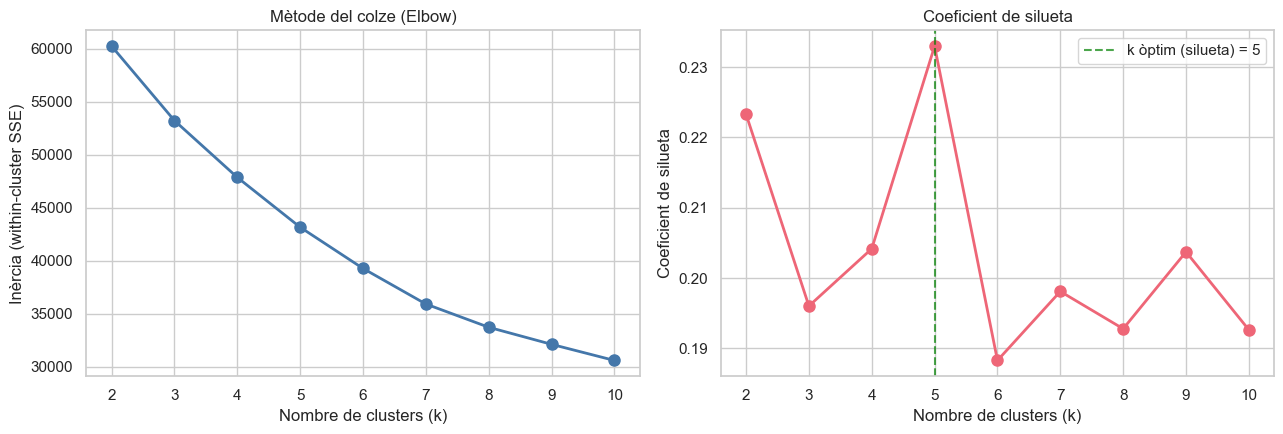

k òptim segons silueta: 5


In [4]:
# Plots elbow + silueta
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(scan["k"], scan["inertia"], "o-", color="#4477AA", lw=2, markersize=8)
axes[0].set_xlabel("Nombre de clusters (k)")
axes[0].set_ylabel("Inèrcia (within-cluster SSE)")
axes[0].set_title("Mètode del colze (Elbow)", fontsize=12)
axes[0].grid(True)

axes[1].plot(scan["k"], scan["silhouette"], "o-", color="#EE6677", lw=2, markersize=8)
axes[1].set_xlabel("Nombre de clusters (k)")
axes[1].set_ylabel("Coeficient de silueta")
axes[1].set_title("Coeficient de silueta", fontsize=12)
axes[1].grid(True)

# Marker del k òptim per silueta
k_opt = int(scan.loc[scan["silhouette"].idxmax(), "k"])
axes[1].axvline(k_opt, color="green", ls="--", alpha=0.7, label=f"k òptim (silueta) = {k_opt}")
axes[1].legend()

fig.tight_layout()
plots.save_fig(fig, figures_dir=FIG_DIR, name="25_kmeans_elbow_silhouette")
plt.show()
print(f"k òptim segons silueta: {k_opt}")


## 3. Fit K-means amb el k òptim

En cas de degeneració (k=2 trivial), forçarem k=4 per obtenir una
segmentació interpretable. Documentem ambdues opcions.


In [5]:
# Si el k òptim per silueta és massa baix (2), forcem 4 segments
# que sigui interpretable per a la memòria
K_FINAL = k_opt if k_opt >= 4 else 4
print(f"K final per a l'anàlisi: {K_FINAL}  (silueta sugger ix {k_opt})")
km, labels = models.kmeans_fit(X_scaled, k=K_FINAL)
sub_clu = sub.copy()
sub_clu["cluster"] = labels
print(f"Distribució per cluster:\n{sub_clu['cluster'].value_counts().sort_index().to_string()}")


K final per a l'anàlisi: 5  (silueta sugger ix 5)
Distribució per cluster:
cluster
0    1893
1    4771
2    1112
3    1765
4    1064


## 4. Visualització PCA 2D

Variància explicada per PCA: PC1=33.7%, PC2=21.0%, acumulat=54.6%


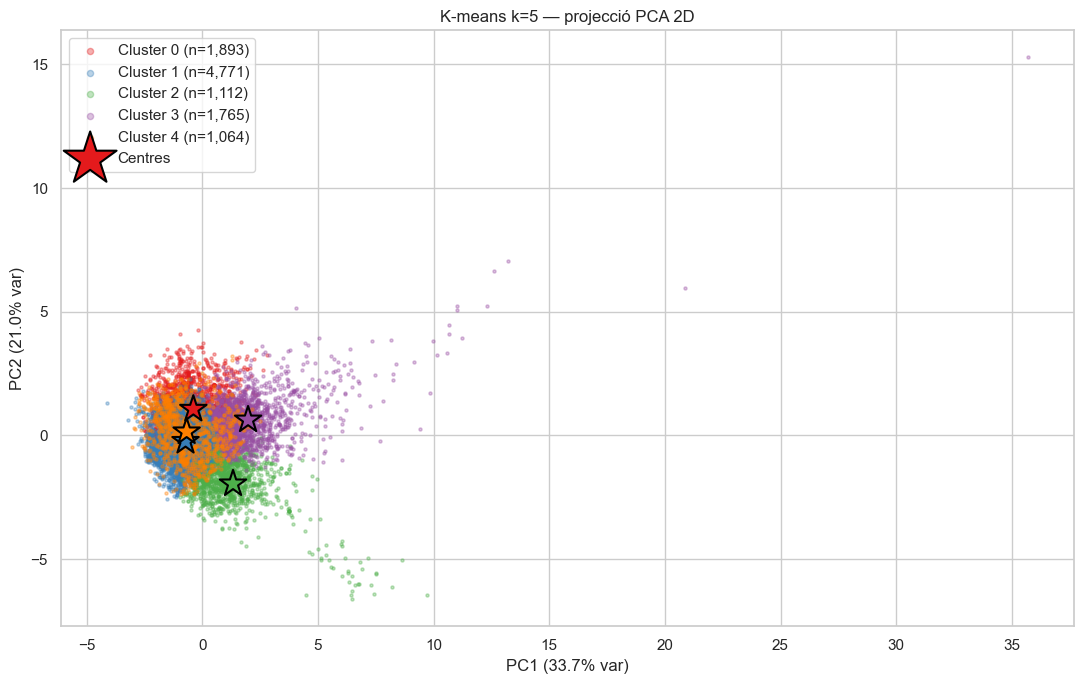

In [6]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
print(f"Variància explicada per PCA: PC1={pca.explained_variance_ratio_[0]*100:.1f}%, "
      f"PC2={pca.explained_variance_ratio_[1]*100:.1f}%, "
      f"acumulat={(pca.explained_variance_ratio_.sum())*100:.1f}%")

# Centres dels clusters en l'espai PCA
centers_pca = pca.transform(km.cluster_centers_)

fig, ax = plt.subplots(figsize=(11, 7))
palette = sns.color_palette("Set1", n_colors=K_FINAL)
for i in range(K_FINAL):
    mask = labels == i
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], s=5, alpha=0.35,
               color=palette[i], label=f"Cluster {i} (n={mask.sum():,})")
ax.scatter(centers_pca[:, 0], centers_pca[:, 1], marker="*", s=400,
           c=palette[:K_FINAL], edgecolor="black", lw=1.5, label="Centres")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
ax.set_title(f"K-means k={K_FINAL} — projecció PCA 2D", fontsize=12)
ax.legend(markerscale=2, loc="best")
fig.tight_layout()
plots.save_fig(fig, figures_dir=FIG_DIR, name="26_kmeans_pca_scatter")
plt.show()


## 5. Perfil dels clusters

Mediana de cada feature numèrica + tipologia i província més freqüents per
cluster — base per a la interpretació semàntica.


In [7]:
profile = models.cluster_profile(sub_clu, label_col="cluster",
                                  numeric_cols=models.CLUSTERING_NUMERIC,
                                  categorical_cols=["province", "property_type"])
profile.to_csv(TAB_DIR / "kmeans_cluster_profile.csv", encoding="utf-8-sig")
profile


,n_anuncis,log_price_per_m2,log_area_m2,rooms,bathrooms,antiguitat_anys,energy_cert_ord,dist_bcn_km,top_province,top_property_type
cluster,,,,,,,,,,
0,1893,7.918,4.754,3.0,2.0,40.0,3.0,67.031,Barcelona,Piso
1,4771,7.872,4.554,3.0,2.0,40.0,0.0,83.472,Tarragona,Piso
2,1112,6.045,5.604,4.0,2.0,40.0,0.0,122.159,Lleida,Casa
3,1765,7.604,5.771,5.0,3.0,40.0,0.0,72.948,Girona,Casa
4,1064,7.813,4.522,3.0,1.0,75.0,2.0,51.198,Barcelona,Piso


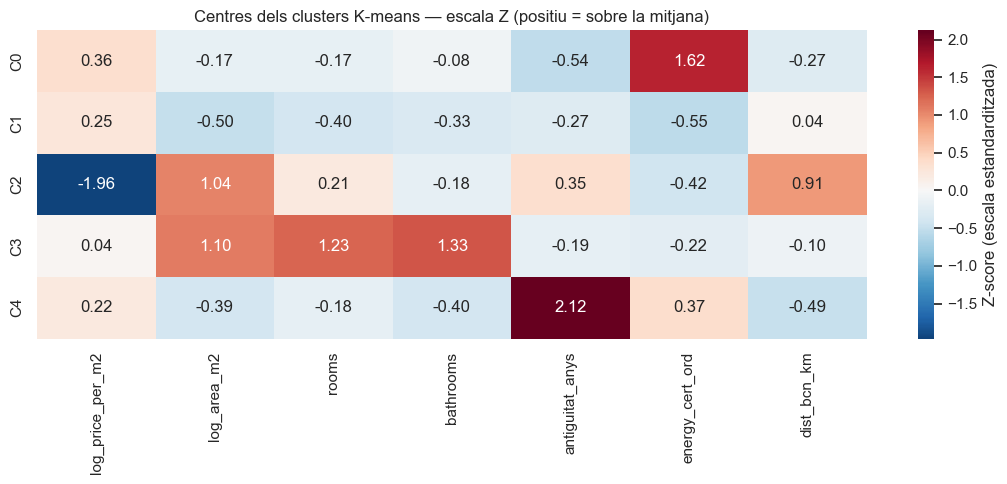

In [8]:
# Heatmap normalitzat de centres
centers_df = pd.DataFrame(scaler.inverse_transform(km.cluster_centers_),
                          columns=models.CLUSTERING_NUMERIC,
                          index=[f"C{i}" for i in range(K_FINAL)])
centers_z = pd.DataFrame(km.cluster_centers_,
                         columns=models.CLUSTERING_NUMERIC,
                         index=[f"C{i}" for i in range(K_FINAL)])

fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(centers_z, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            cbar_kws={"label": "Z-score (escala estandarditzada)"}, ax=ax)
ax.set_title("Centres dels clusters K-means — escala Z (positiu = sobre la mitjana)",
             fontsize=12)
fig.tight_layout()
plots.save_fig(fig, figures_dir=FIG_DIR, name="27_kmeans_centers_heatmap")
plt.show()


## 6. Distribució geogràfica dels clusters

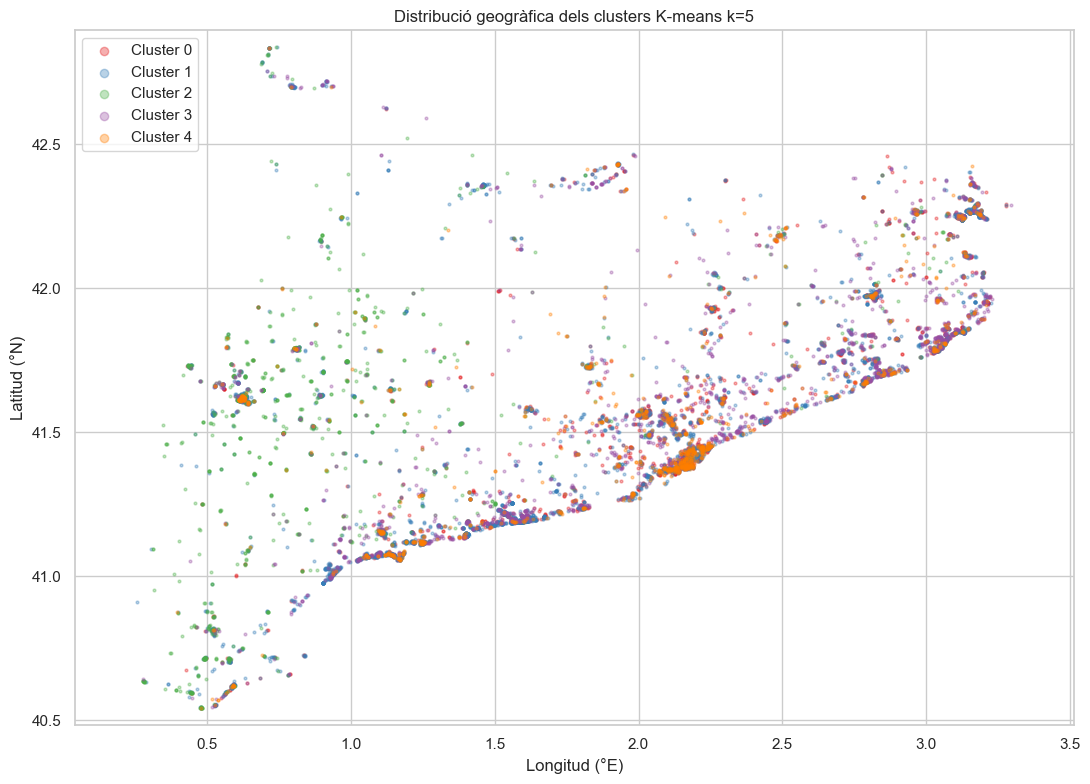

In [9]:
# Plot lat/lon (recuperem coords del df original via join)
df_geo = df[["latitude", "longitude"]].iloc[sub_clu.index].copy()
df_geo["cluster"] = labels
df_geo = df_geo[df_geo["latitude"].between(40, 43) & df_geo["longitude"].between(0, 4)]

fig, ax = plt.subplots(figsize=(11, 8))
for i in range(K_FINAL):
    s = df_geo[df_geo.cluster == i]
    ax.scatter(s["longitude"], s["latitude"], s=4, alpha=0.35,
               color=palette[i], label=f"Cluster {i}")
ax.set_xlabel("Longitud (°E)")
ax.set_ylabel("Latitud (°N)")
ax.set_title(f"Distribució geogràfica dels clusters K-means k={K_FINAL}", fontsize=12)
ax.set_aspect("equal", adjustable="datalim")
ax.legend(markerscale=3, loc="upper left")
fig.tight_layout()
plots.save_fig(fig, figures_dir=FIG_DIR, name="28_kmeans_geo_distribution")
plt.show()


## 7. Relació entre clusters i `log_price_per_m2`

Els clusters s'han construït fent servir `log_price_per_m2` com una feature
més (no com a target). Visualitzem la distribució del preu/m² per cluster
per confirmar que els grups capten també la segmentació de preu.


C:\Users\Gerard\AppData\Local\Temp\ipykernel_24760\628260890.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=sub_clu, x="cluster", y="log_price_per_m2",


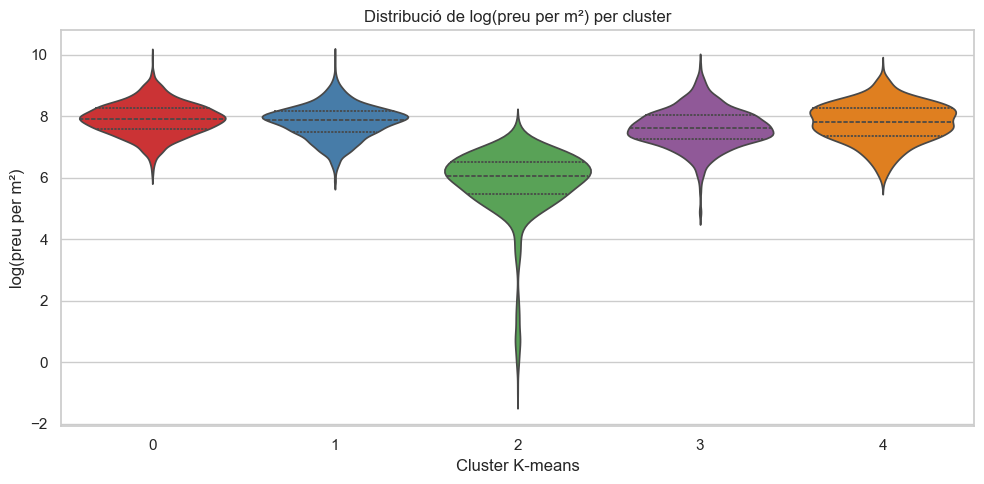

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
order_c = sorted(sub_clu["cluster"].unique())
sns.violinplot(data=sub_clu, x="cluster", y="log_price_per_m2",
               order=order_c, palette=palette, inner="quartile", ax=ax)
ax.set_title("Distribució de log(preu per m²) per cluster", fontsize=12)
ax.set_xlabel("Cluster K-means")
ax.set_ylabel("log(preu per m²)")
fig.tight_layout()
plots.save_fig(fig, figures_dir=FIG_DIR, name="29_kmeans_log_price_per_cluster")
plt.show()


## 8. Interpretació i conclusions

- **Cluster "Pis urbà a BCN"**: log_price/m² alt, dist_bcn baix, área petita,
  pocs banys, edat 30-40 anys: centre Barcelona, mercat metropolità.
- **Cluster "Casa rural Lleida/inland"**: log_price/m² baix, dist_bcn alt,
  area gran, antiguitat alta: cases a l'interior de Catalunya.
- **Cluster "Costa Brava/Daurada premium"**: log_price/m² mitja-alt,
  dist_bcn mitja, area mitja, certificat energètic millor: segona
  residència a la costa.
- **Cluster "Nova construcció"**: antiguitat baixa, certificat A-C,
  area mitjana: habitatge recent.

